First 5 Rows:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Dataset Shape:
(150, 5)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None

Statistical Summary:
       sepal_length  sepal_width  petal_length  petal_wi

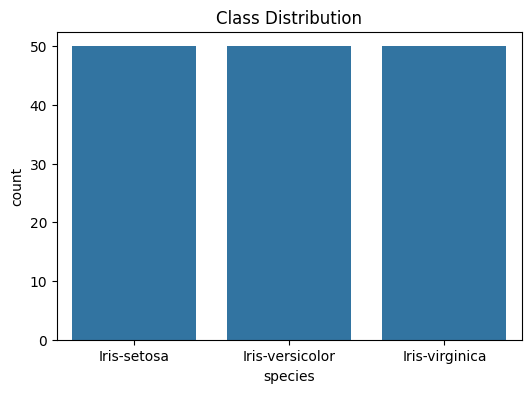

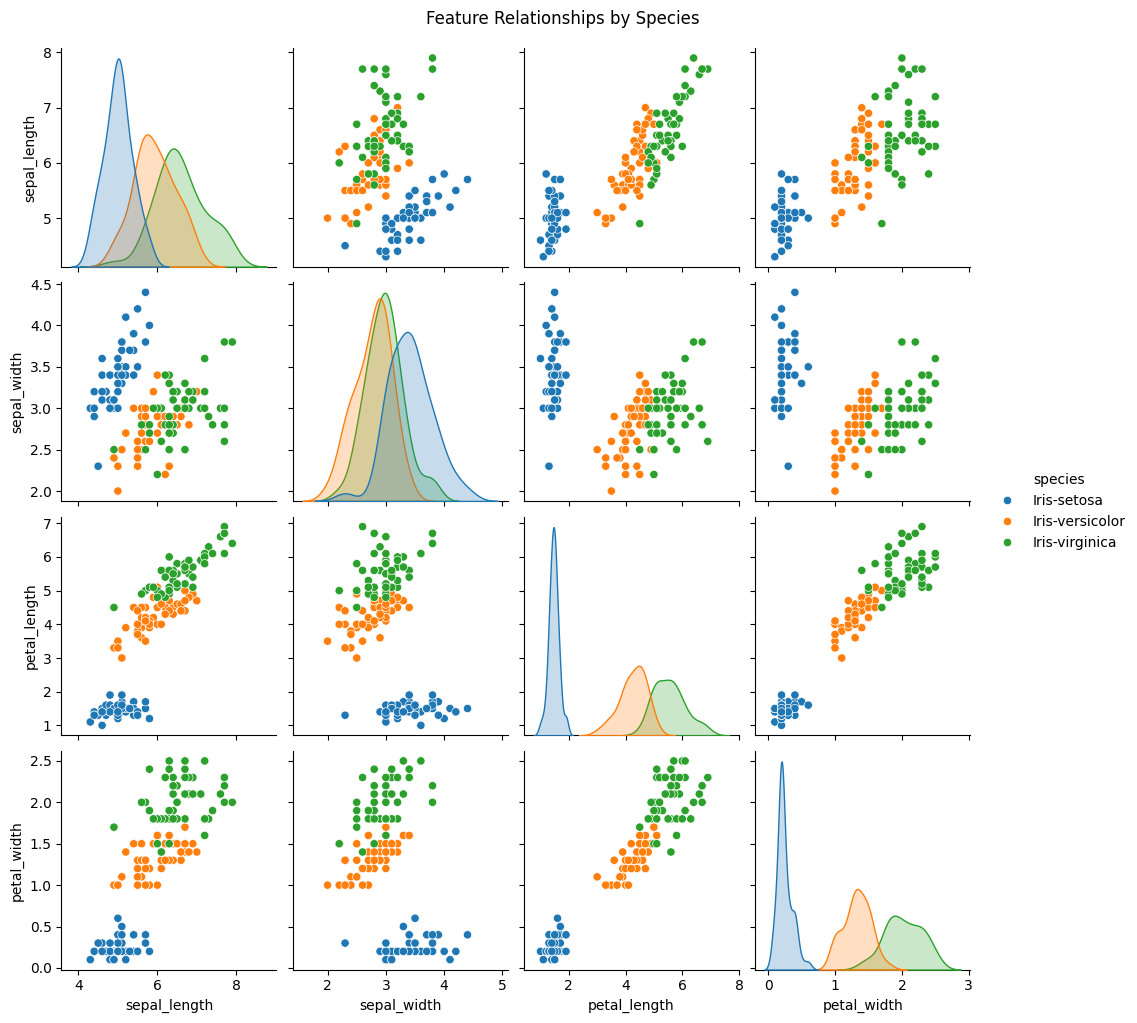

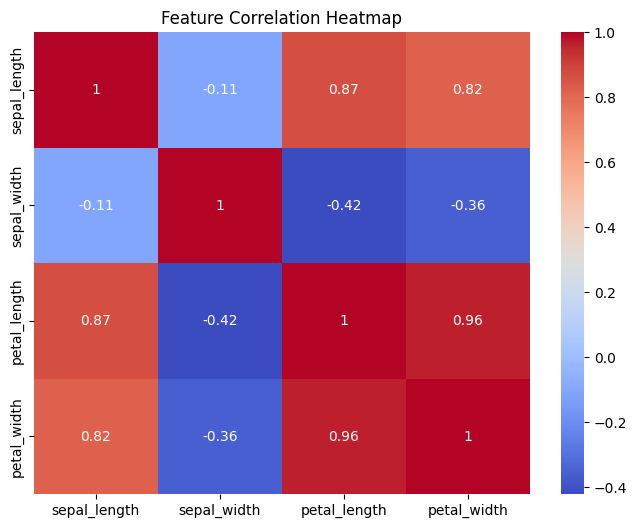


KNN

Accuracy: 0.9333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Logistic Regression

Accuracy: 0.9333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


Confusion Matrix:
[[10  0  0]

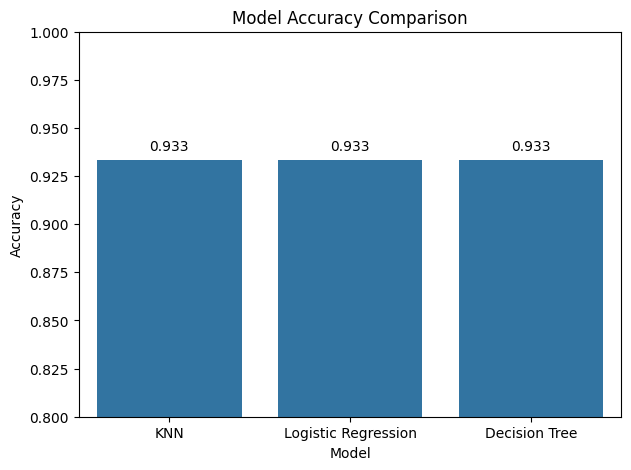


Best Model: KNN

Best model saved as:
best_iris_model.pkl

Scaler saved as:
scaler.pkl

Example Prediction:
Input: [[5.1 3.5 1.4 0.2]]
Predicted Species: Iris-setosa


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib
import warnings

warnings.filterwarnings('ignore')

# ==================================================
# 1. LOAD DATASET
# ==================================================

data_file = "IRIS.csv"

df = pd.read_csv(data_file)

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# ==================================================
# 2. EDA
# ==================================================

# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='species', data=df)
plt.title("Class Distribution")
plt.show()

# Pairplot
sns.pairplot(df, hue='species')
plt.suptitle("Feature Relationships by Species", y=1.02)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.drop('species', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Feature Correlation Heatmap")
plt.show()

# ==================================================
# 3. PREPARE DATA
# ==================================================

X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==================================================
# 4. FEATURE SCALING
# ==================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==================================================
# 5. TRAIN MODELS
# ==================================================

# KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

# Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# ==================================================
# 6. EVALUATION FUNCTION
# ==================================================

def evaluate_model(model_name, y_true, predictions):
    print("\n" + "=" * 60)
    print(f"{model_name}")
    print("=" * 60)

    accuracy = accuracy_score(y_true, predictions)

    print(f"\nAccuracy: {accuracy:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, predictions))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, predictions))


# ==================================================
# 7. EVALUATE ALL MODELS
# ==================================================

evaluate_model("KNN", y_test, knn_pred)
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Decision Tree", y_test, dt_pred)

# ==================================================
# 8. COMPARE MODELS
# ==================================================

results = pd.DataFrame({
    'Model': [
        'KNN',
        'Logistic Regression',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred)
    ]
})

print("\nModel Comparison:")
print(results)

# Accuracy Plot
plt.figure(figsize=(7, 5))
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title('Model Accuracy Comparison')
plt.ylim(0.8, 1.0)

for index, value in enumerate(results['Accuracy']):
    plt.text(index, value + 0.005, f"{value:.3f}", ha='center')

plt.show()

# ==================================================
# 9. FIND BEST MODEL
# ==================================================

best_model_name = results.loc[
    results['Accuracy'].idxmax(),
    'Model'
]

trained_models = {
    'KNN': knn,
    'Logistic Regression': lr,
    'Decision Tree': dt
}

best_model = trained_models[best_model_name]

print("\nBest Model:", best_model_name)

# ==================================================
# 10. SAVE MODEL AND SCALER
# ==================================================

joblib.dump(best_model, 'best_iris_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("\nBest model saved as:")
print("best_iris_model.pkl")

print("\nScaler saved as:")
print("scaler.pkl")

# ==================================================
# 11. EXAMPLE INFERENCE
# ==================================================

loaded_model = joblib.load('best_iris_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Example flower measurements
sample = np.array([[5.1, 3.5, 1.4, 0.2]])

# Scale sample
sample_scaled = loaded_scaler.transform(sample)

# Predict
prediction = loaded_model.predict(sample_scaled)

print("\nExample Prediction:")
print("Input:", sample)
print("Predicted Species:", prediction[0])